# test_2 — ¿el test set mide generalización real?

`test_1.ipynb` reportó, sobre `models/full_model`, **accuracy 0.9960 / macro F1 0.9789**
en el set de test held-out (`data/id_seqs_text_2000_2022_test_set.zip`).

Al armar un mapa de las zonas de entrenamiento y de test (`scripts/plot_train_test_zones.py`,
`imgs/train_test_zones.png`) con las coordenadas subidas en `data/lat_long_df_*.zip`,
apareció algo raro: la huella geográfica del set de entrenamiento queda completamente
contenida dentro de la del set de test. Este notebook documenta la investigación de
por qué, y recalcula una métrica de generalización honesta.


In [ ]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

from land2vec.dataset import load_data
from land2vec.tokenizer import Tokenizer
from land2vec.model import GPTDecoder
from land2vec.utils import load_config, compute_metrics


## Cargar el modelo final (`models/full_model`)

In [1]:
target_folder = Path("models") / "full_model"
config = load_config(target_folder)
config.device = "cpu"  # esta corrida no tiene GPU disponible

model = GPTDecoder(
    vocab_size=len(Tokenizer.VOCAB),
    block_size=config.block_size,
    n_embd=config.n_embd,
    n_head=config.n_head,
    n_layer=config.n_layer,
    dropout=config.dropout,
)
# el checkpoint se guardo con tensores CUDA; map_location lo trae a CPU
state = torch.load(target_folder / "model.pt", map_location="cpu")
model.load_state_dict(state)
model = model.to(config.device)
model.eval()

print(f"parametros: {sum(p.numel() for p in model.parameters()):,}")


parametros: 795,520


## ¿El test set es geográficamente distinto del set de entrenamiento?

Cruzamos, por coordenada exacta (`latitude`, `longitude` redondeadas a 5 decimales,
~1m de precisión), las parcelas de `data/lat_long_df_chaco_santiago_frontier.zip`
(entrenamiento) contra `data/lat_long_df_test_set.zip` (test).


In [2]:
train_geo = pd.read_csv("data/lat_long_df_chaco_santiago_frontier.zip")
test_geo = pd.read_csv("data/lat_long_df_test_set.zip")

train_geo["key"] = train_geo.latitude.round(5).astype(str) + "_" + train_geo.longitude.round(5).astype(str)
test_geo["key"] = test_geo.latitude.round(5).astype(str) + "_" + test_geo.longitude.round(5).astype(str)

train_keys = set(train_geo["key"])
test_geo = test_geo.sort_values("ID").reset_index(drop=True)
leaked_mask = test_geo["key"].isin(train_keys).to_numpy()

print(f"parcelas de train: {len(train_geo):,}")
print(f"parcelas de test:  {len(test_geo):,}")
print(f"parcelas de test que tambien estan en train: {leaked_mask.sum():,} ({leaked_mask.mean()*100:.1f}%)")
print(f"parcelas de train que aparecen en test: {train_geo['key'].isin(set(test_geo['key'])).mean()*100:.1f}%")


parcelas de train: 1,424,457
parcelas de test:  2,487,780
parcelas de test que tambien estan en train: 1,424,457 (57.3%)
parcelas de train que aparecen en test: 100.0%


**El 100% de las parcelas de entrenamiento reaparecen en el test set.** No es una
zona geográfica separada: es (al menos parcialmente) el mismo terreno.

## ¿Son literalmente la misma parcela, o coordenadas cercanas por casualidad?

Tomamos 5 coordenadas al azar que aparecen en ambos archivos, y comparamos la
secuencia real (`seqs`) asociada a cada una en el CSV de train vs. en el de test.


In [3]:
import zipfile, csv, random

def fetch_rows(zip_path, wanted_ids):
    result = {}
    with zipfile.ZipFile(zip_path) as z:
        name = z.namelist()[0]
        with z.open(name) as f:
            r = csv.reader((line.decode() for line in f))
            next(r)
            for row in r:
                _id = int(row[0])
                if _id in wanted_ids:
                    result[_id] = row[1]
                    if len(result) == len(wanted_ids):
                        break
    return result

train_map = dict(zip(train_geo.key, train_geo.ID))
test_map = dict(zip(test_geo.key, test_geo.ID))
common_keys = list(set(train_map) & set(test_map))

random.seed(0)
sample_keys = random.sample(common_keys, 5)
pairs = [(train_map[k], test_map[k], k) for k in sample_keys]

train_seqs = fetch_rows("data/id_seqs_text_2000_2022_chaco_santiago_frontier.zip", {p[0] for p in pairs})
test_seqs = fetch_rows("data/id_seqs_text_2000_2022_test_set.zip", {p[1] for p in pairs})

for train_id, test_id, key in pairs:
    print(f"coord={key} train_ID={train_id} test_ID={test_id} match={train_seqs[train_id] == test_seqs[test_id]}")


coord=-26.90139_-63.12083 train_ID=776161 test_ID=894466 match=True
coord=-27.40972_-62.97361 train_ID=1044675 test_ID=1192077 match=True
coord=-25.65972_-59.37639 train_ID=121760 test_ID=168992 match=True
coord=-27.32361_-59.40139 train_ID=1000484 test_ID=1142957 match=True
coord=-26.47917_-63.16528 train_ID=553161 test_ID=647298 match=True


Las 5 son idénticas byte a byte. No es cercanía espacial: es la misma parcela,
con la misma secuencia de estados, repetida entre ambos archivos.

## ¿Cómo evalúa `test_1.ipynb`?

```python
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=config.batch_size, ...)
...
collect_predictions(model, test_loader, config.device, weights, max_batches=200)
```

`shuffle=False` + `max_batches=200` con `batch_size=1024` implica evaluar **solo las
primeras 204.800 filas** del archivo (el 8% inicial, en el orden en que están
guardadas) — no una muestra representativa del test set completo.


In [4]:
evaluated_first = test_geo[test_geo.ID < 200 * 1024]
print(f"filas evaluadas en test_1.ipynb: {len(evaluated_first):,}")
print(f"de esas, tambien vistas en train: {evaluated_first['key'].isin(train_keys).mean()*100:.1f}%")


filas evaluadas en test_1.ipynb: 204,800
de esas, tambien vistas en train: 75.2%


75.2% de lo que `test_1.ipynb` reporta como "test" son parcelas que el modelo
ya vio en entrenamiento — más que el 57.3% del test set completo.

## Evaluación completa, trackeando cada fila

En vez de aplanar todas las predicciones (como hace `collect_predictions`), corremos
inferencia sobre **todo** el test set (sin `max_batches`, `shuffle=False`) pero
guardamos a qué fila/ID original pertenece cada predicción, para poder recortar
por leakage después sin tener que re-correr el modelo.


In [5]:
test_dataset = load_data(file_path=Path("data") / "id_seqs_text_2000_2022_test_set.zip")
assert len(test_dataset) == len(test_geo)

loader = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=False, num_workers=0)

all_preds, all_targets, all_row_ids = [], [], []
row_cursor = 0
model.eval()
with torch.inference_mode():
    for x, y in loader:
        bsz, seqlen = x.shape
        logits = model(x)
        preds = logits.argmax(dim=-1)
        row_ids_batch = torch.arange(row_cursor, row_cursor + bsz).repeat_interleave(seqlen)
        all_preds.append(preds.reshape(-1))
        all_targets.append(y.reshape(-1))
        all_row_ids.append(row_ids_batch)
        row_cursor += bsz

all_preds = torch.cat(all_preds).numpy()
all_targets = torch.cat(all_targets).numpy()
all_row_ids = torch.cat(all_row_ids).numpy()
leaked_by_token = leaked_mask[all_row_ids]

print(f"predicciones totales (fila x posicion): {len(all_preds):,}")


predicciones totales (fila x posicion): 54,731,160


> Nota: esta celda tarda ~10 minutos en CPU (2.487.780 secuencias x 22 posiciones).
> Con GPU corre en segundos.

## Comparación: como `test_1.ipynb` vs. test completo vs. test limpio vs. solo leaked


In [6]:
mask_test1 = all_row_ids < 200 * 1024
mask_full = np.ones_like(mask_test1, dtype=bool)
mask_clean = ~leaked_by_token
mask_leaked = leaked_by_token

rows = []
for name, mask in [
    ("como test_1.ipynb (primeras 204.800 filas)", mask_test1),
    ("test set completo", mask_full),
    ("test set limpio (sin leakage)", mask_clean),
    ("solo filas leaked (en todo el archivo)", mask_leaked),
]:
    n_rows = len(np.unique(all_row_ids[mask]))
    pct_leaked = leaked_by_token[mask].mean() * 100
    m = compute_metrics(all_targets[mask], all_preds[mask])
    rows.append((name, n_rows, pct_leaked, m["accuracy"], m["macro_f1"]))
    print(f"{name:45s} filas={n_rows:>10,} leaked={pct_leaked:5.1f}% accuracy={m['accuracy']:.4f} macro_f1={m['macro_f1']:.4f}")


como test_1.ipynb (primeras 204.800 filas)   filas=   204,800 leaked= 75.2% accuracy=0.9960 macro_f1=0.9789
test set completo                            filas= 2,487,780 leaked= 57.3% accuracy=0.9922 macro_f1=0.9003
test set limpio (sin leakage)                filas= 1,063,323 leaked=  0.0% accuracy=0.9929 macro_f1=0.9005
solo filas leaked (en todo el archivo)        filas= 1,424,457 leaked=100.0% accuracy=0.9916 macro_f1=0.9891


El **accuracy** apenas se mueve (0.991–0.996 en todos los casos): la clase mayoritaria
(sin cambio de estado interanual) es fácil de acertar en cualquier parte del mapa.

El **macro F1** sí se mueve mucho: 0.9891 en filas leaked vs. 0.9005 en filas limpias.
El número que reportaba `test_1.ipynb` (0.9789) está mucho más cerca del primero
porque su muestra (75% leaked) está dominada por parcelas ya vistas.

## Por qué la brecha es tan grande: la clase `B` prácticamente no existe en las
## zonas de entrenamiento

`compute_metrics` calcula el F1 macro solo sobre las clases *presentes* en cada
evaluación (comportamiento por default de `sklearn.metrics.f1_score`), no sobre
las 11 clases fijas del vocabulario. Eso importa acá:


In [7]:
for name, mask in [("leaked", mask_leaked), ("clean", mask_clean)]:
    vals, counts = np.unique(all_targets[mask], return_counts=True)
    present = {Tokenizer.REVERSE_VOCAB[v]: int(c) for v, c in zip(vals, counts)}
    print(name, present)

print()
for name, mask in [("leaked", mask_leaked), ("clean", mask_clean)]:
    yt, yp = all_targets[mask], all_preds[mask]
    f1_presentes = f1_score(yt, yp, average="macro")
    f1_fijo = f1_score(yt, yp, average="macro", labels=list(range(len(Tokenizer.VOCAB))), zero_division=0)
    print(f"{name}: macro_f1 (clases presentes)={f1_presentes:.4f} | macro_f1 (11 clases fijas)={f1_fijo:.4f}")


leaked {'A': 9603841, 'F': 15349878, 'G': 129621, 'Wt': 445859, 'U': 20592, 'Sh': 5721676, 'Sp': 12750, 'Wa': 53837}
clean {'A': 8181508, 'F': 6476440, 'G': 66083, 'Wt': 2518585, 'U': 16981, 'Sh': 5731028, 'Sp': 13754, 'B': 107, 'Wa': 388620}

leaked: macro_f1 (clases presentes)=0.9891 | macro_f1 (11 clases fijas)=0.7194
clean: macro_f1 (clases presentes)=0.9005 | macro_f1 (11 clases fijas)=0.7368


La clase **`B`** (107 ocurrencias en 22 años x ~1M parcelas — es rarísima) **no
aparece ni una sola vez como target real en el subconjunto leaked**, así que
`compute_metrics` ni la considera ahí; en el subconjunto limpio sí aparece, el
modelo la predice mal (ver matriz de confusión abajo), y al ser macro (todas las
clases pesan igual) hunde el promedio.

Con un set de clases fijo (las 11 del vocabulario, `zero_division=0`) los dos
subconjuntos quedan mucho más parecidos entre sí (0.72 vs 0.74) — la métrica
"macro F1 sobre clases presentes" no es comparable entre evaluaciones con
composición de clases distinta, independientemente del leakage.


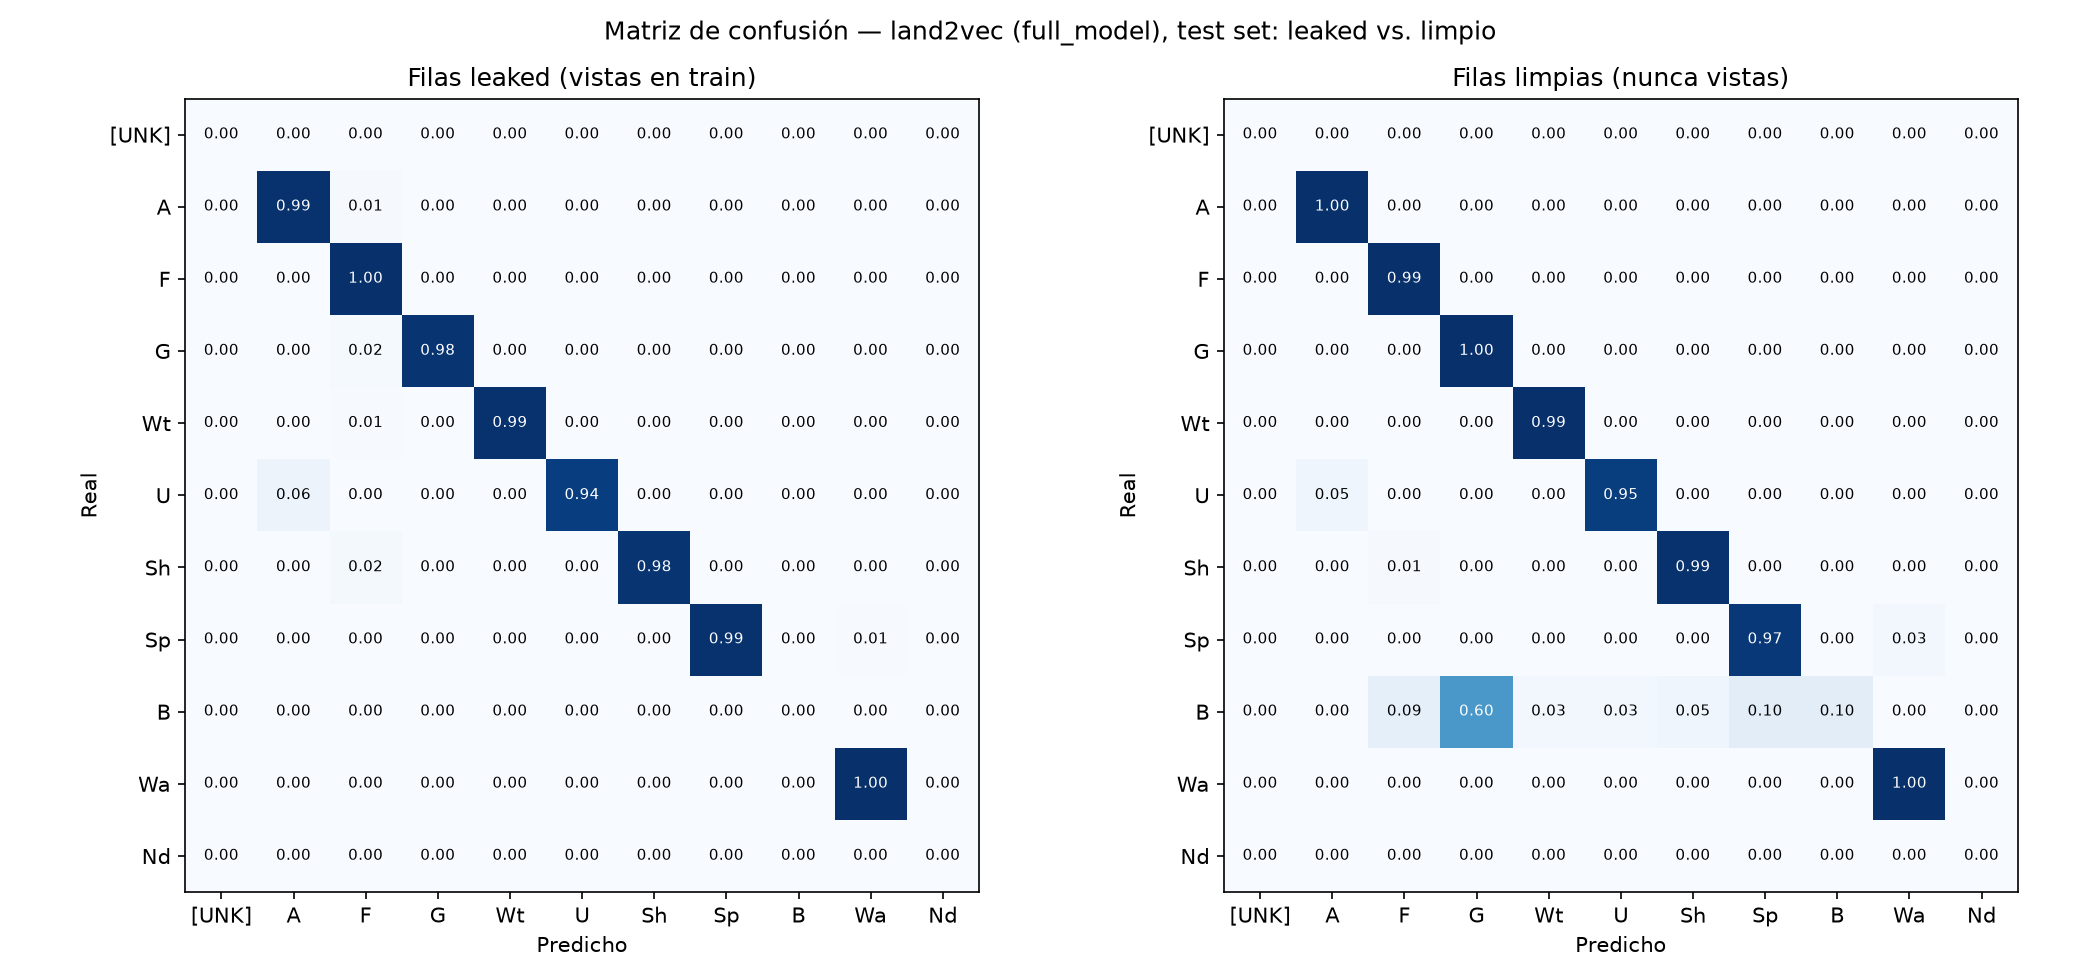

In [8]:
valid_ids = sorted(Tokenizer.REVERSE_VOCAB.keys())
labels = [Tokenizer.REVERSE_VOCAB[i] for i in valid_ids]

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
for ax, mask, title in [
    (axes[0], mask_leaked, "Filas leaked (vistas en train)"),
    (axes[1], mask_clean, "Filas limpias (nunca vistas)"),
]:
    cm = confusion_matrix(all_targets[mask], all_preds[mask], labels=valid_ids, normalize="true")
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format=".2f")
    ax.set_title(title)
    ax.grid(False)
fig.suptitle("Matriz de confusion -- land2vec (full_model), test set: leaked vs. limpio")
fig.tight_layout()
plt.show()


## Conclusión

1. **El test set no es un hold-out espacial**: el 100% de las parcelas de
   entrenamiento reaparecen en él, con secuencia idéntica.
2. **`test_1.ipynb` además evalúa una porción no aleatoria** (las primeras
   204.800 filas, `shuffle=False` + `max_batches=200`), que resulta tener más
   leakage (75.2%) que el test set completo (57.3%).
3. El **accuracy** casi no se ve afectado por ninguno de los dos problemas
   (~0.99 en todos los casos) porque la clase dominante es trivial.
4. El **macro F1** sí, y no solo por memorización: la clase rara `B` está
   ausente del área de entrenamiento, así que `compute_metrics` (que promedia
   solo sobre clases presentes) ni la contempla al evaluar filas leaked.

**Número honesto de generalización** (test set limpio, sin leakage, con
`compute_metrics` tal como está definido hoy en el repo):

- **Accuracy: 0.9929**
- **Macro F1: 0.9005**

Sujeto a una advertencia adicional: como `compute_metrics` promedia solo sobre
clases presentes, este 0.9005 tampoco es directamente comparable con macro-F1
de otras corridas si la composición de clases del set evaluado cambia. Para
comparaciones futuras conviene fijar `labels=` a las clases del vocabulario.

**Recomendación**: para reportar generalización espacial real, reconstruir el
test set a partir de parcelas efectivamente disjuntas de las usadas en
entrenamiento (filtrando por coordenada, como se hizo acá), en vez de
re-extraer una región que las englobe.
